# PEANUTS solar-neutrino energy spectrum

This teacher-side notebook builds the lecture figure from PEANUTS solar-model tables. Students do not need PEANUTS: the generated PNG and CSV files are committed to the project site.

The plotted quantity for continuum sources is

$$
\frac{d\Phi_i}{dE_\nu}=\Phi_i f_i(E_\nu),
$$

where $f_i$ is normalized to unit integral. Line sources are drawn as vertical markers at their integrated flux.

In [1]:
#| echo: true
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd


def find_masterclass_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "scripts" / "generate_peanuts_solar_spectrum.py").exists():
            return candidate
        nested = candidate / "solar-neutrino-masterclass"
        if (nested / "scripts" / "generate_peanuts_solar_spectrum.py").exists():
            return nested
    raise RuntimeError("Cannot locate solar-neutrino-masterclass")


ROOT = find_masterclass_root()
REPO_ROOT = ROOT.parent
PEANUTS_ROOT = REPO_ROOT / ".external" / "PEANUTS"

if str(PEANUTS_ROOT) not in sys.path:
    sys.path.insert(0, str(PEANUTS_ROOT))

# Compatibility for current PEANUTS with newer SciPy.
import scipy.integrate as scipy_integrate
if not hasattr(scipy_integrate, "trapz"):
    scipy_integrate.trapz = np.trapz

print("masterclass root:", ROOT)
print("PEANUTS root:", PEANUTS_ROOT)

masterclass root: /Users/dmitrijnaumov/Documents/NeutrinoHit/neutrinophysics/solar-neutrino-masterclass
PEANUTS root: /Users/dmitrijnaumov/Documents/NeutrinoHit/neutrinophysics/.external/PEANUTS


## Load the PEANUTS solar model

`SolarModel()` loads the default B16 AGSS09 tables distributed with PEANUTS: total fluxes, production profiles and spectral shapes.

In [2]:
#| echo: true
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    from peanuts.solar import SolarModel
    solar = SolarModel()

sources = ["pp", "pep", "hep", "7Be", "8B", "13N", "15O", "17F"]
fluxes = pd.DataFrame(
    [(source, solar.flux(source)) for source in sources],
    columns=["source", "flux_cm2_s"],
)
fluxes

,source,flux_cm2_s
0,pp,6.030000e+10
1,pep,1.460000e+08
2,hep,8.250000e+03
3,7Be,4.500000e+09
4,8B,4.500000e+06
5,13N,2.040000e+08
6,15O,1.440000e+08
7,17F,3.260000e+06


## Build continuum spectra

PEANUTS tabulates normalized shapes for the continuum sources. We renormalize numerically on the tabulated grid and then multiply by the total source flux.

In [3]:
#| echo: true
def trapz(y, x):
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


def normalized_shape(table: pd.DataFrame) -> pd.DataFrame:
    out = table[["Energy", "Spectrum"]].copy()
    out = out.rename(columns={"Energy": "E_MeV", "Spectrum": "spectrum_per_MeV"})
    out = out.sort_values("E_MeV")
    out = out[out["E_MeV"] > 0.0]
    area = trapz(out["spectrum_per_MeV"].to_numpy(float), out["E_MeV"].to_numpy(float))
    out["spectrum_per_MeV"] = out["spectrum_per_MeV"] / area
    return out


continuous_sources = ["pp", "13N", "15O", "17F", "8B", "hep"]
rows = []
for source in continuous_sources:
    table = normalized_shape(solar.spectrum(source))
    flux = float(solar.flux(source))
    table["source"] = source
    table["flux_cm2_s"] = flux
    table["flux_per_MeV_cm2_s"] = flux * table["spectrum_per_MeV"]
    rows.append(table[["source", "E_MeV", "spectrum_per_MeV", "flux_cm2_s", "flux_per_MeV_cm2_s"]])

spectrum = pd.concat(rows, ignore_index=True)
spectrum.head()

,source,E_MeV,spectrum_per_MeV,flux_cm2_s,flux_per_MeV_cm2_s
0,pp,0.00504,0.0035,6.030000e+10,2.110512e+08
1,pp,0.01008,0.0138,6.030000e+10,8.321446e+08
2,pp,0.01512,0.0307,6.030000e+10,1.851220e+09
3,pp,0.02016,0.0538,6.030000e+10,3.244158e+09
4,pp,0.02520,0.0830,6.030000e+10,5.004927e+09


## Add line sources

The conventional solar-neutrino spectrum plot draws line sources as vertical markers. Here we include the two main $^7$Be lines and the pep line.

In [4]:
#| echo: true
line_sources = [
    {"source": "7Be", "E_MeV": 0.384, "flux_fraction": 0.103, "uncertainty": "7%"},
    {"source": "7Be", "E_MeV": 0.862, "flux_fraction": 0.897, "uncertainty": "7%"},
    {"source": "pep", "E_MeV": 1.445, "flux_fraction": 1.000, "uncertainty": "1.2%"},
]
lines = pd.DataFrame(line_sources)
lines["total_source_flux_cm2_s"] = lines["source"].map(lambda source: float(solar.flux(source)))
lines["line_flux_cm2_s"] = lines["total_source_flux_cm2_s"] * lines["flux_fraction"]
lines

,source,E_MeV,flux_fraction,uncertainty,total_source_flux_cm2_s,line_flux_cm2_s
0,7Be,0.384,0.103,7%,4.500000e+09,4.635000e+08
1,7Be,0.862,0.897,7%,4.500000e+09,4.036500e+09
2,pep,1.445,1.000,1.2%,1.460000e+08,1.460000e+08


## Save the CSV tables and figure

The helper script only formats the plot. The physical content is the table construction above: $f_i(E)$ from PEANUTS and $\Phi_i f_i(E)$ for the differential flux.

wrote: /Users/dmitrijnaumov/Documents/NeutrinoHit/neutrinophysics/solar-neutrino-masterclass/assets/figures/peanuts_solar_neutrino_spectrum.png


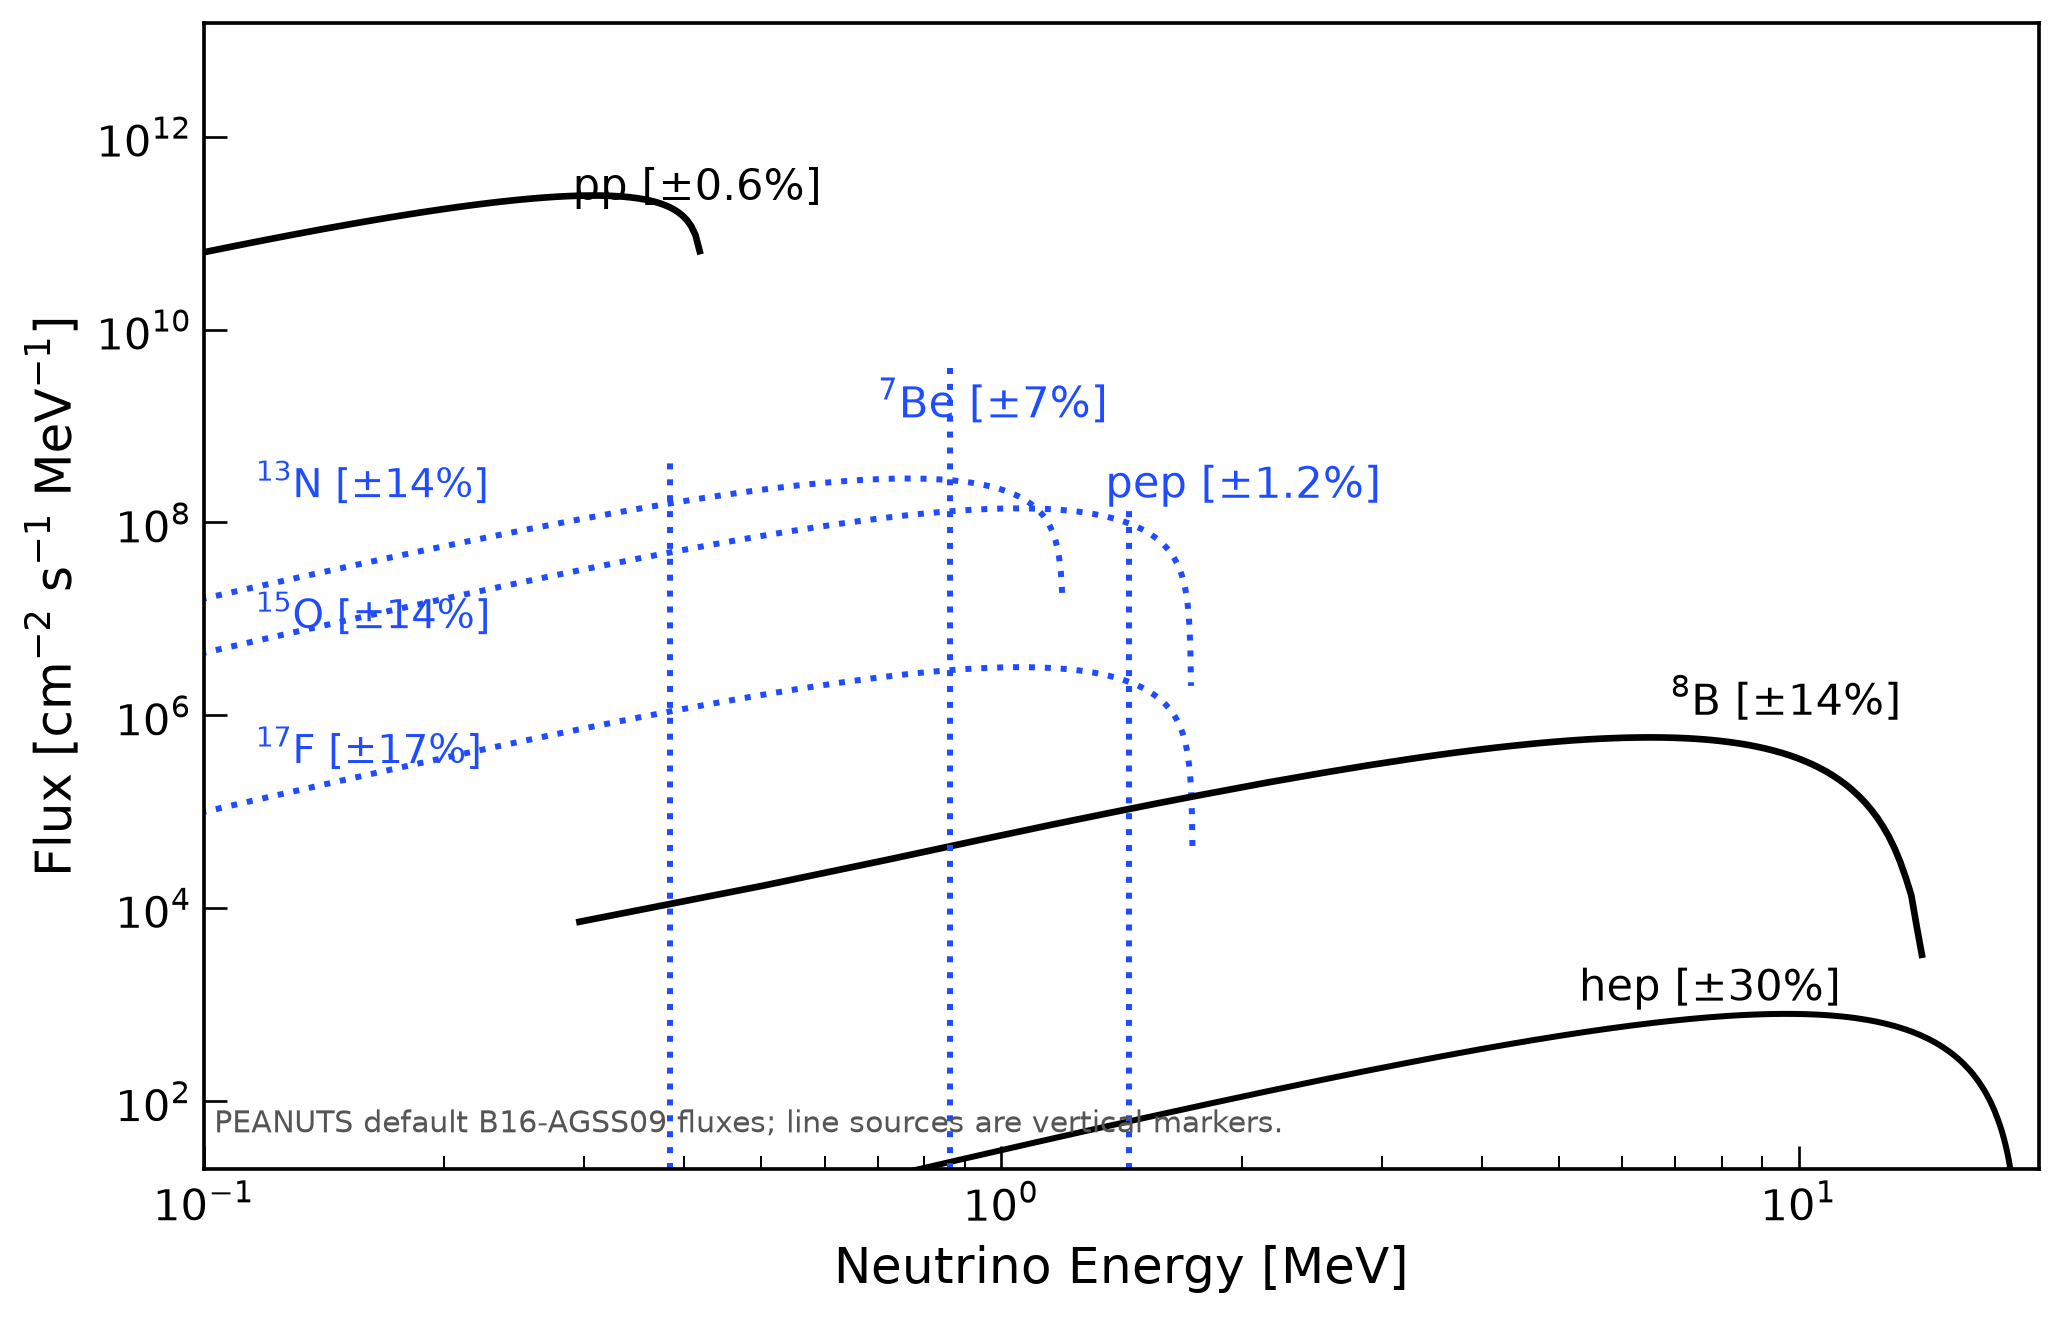

In [5]:
#| echo: true
import importlib.util
from IPython.display import Image, display

script_path = ROOT / "scripts" / "generate_peanuts_solar_spectrum.py"
spec = importlib.util.spec_from_file_location("peanuts_spectrum", script_path)
module = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = module
spec.loader.exec_module(module)

module.save_tables(spectrum, lines)
module.update_student_archive()
module.plot_spectrum(spectrum, lines)

figure_path = ROOT / "assets" / "figures" / "peanuts_solar_neutrino_spectrum.png"
print("wrote:", figure_path)
display(Image(filename=str(figure_path)))